# Haar wavelet rediscovery with bloat control

Same setup as [`haar.ipynb`](haar.ipynb), but we run two (1+1)-ES
searches from the same seed:

- **A** — selection by raw MSE.
- **B** — selection by `MSE + λ · n_active`; the penalty is added
  *after* the LM solve, so the gradient step still fits MSE only.

`wavegp_jax` evaluates all `g.n` internal nodes regardless of
reachability (required for `lax.scan` static shapes), so it doesn't
expose an active-node count. We call `wavegp.reachable_nodes`
host-side once per generation — negligible at G=100, g.n=6.

**Runtime:** ~5 min on a Colab CPU runtime.

## Install

This cell installs the `wavegp-public` library from its GitHub repository. The `-q` flag keeps the installation quiet.

In [1]:
!pip install -q "git+https://github.com/cselab/wavegp-public.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Setup

This cell imports the necessary libraries for the notebook:
- `random`, `time`: Standard Python libraries for random number generation and time measurements.
- `jax`, `jax.numpy`, `numpy`: JAX for numerical computation, especially for automatic differentiation and GPU acceleration.
- `matplotlib.pyplot`: For plotting and visualization.
- `wavegp`, `wavegp_jax`, `wavegp_lm`: Custom libraries for Wavelet Genetic Programming, including JAX-compatible operations and a Levenberg-Marquardt solver.

In [2]:
import random
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import wavegp
import wavegp_jax
import wavegp_lm

## Op vocabulary and target (identical to `haar.ipynb`)

This section defines the genetic programming system's operator vocabulary and the target data for the Haar wavelet rediscovery task.

- **`class g`**: Defines the properties of the genetic program, including operator names, arity (number of inputs), and other structural parameters.
- **`all_ops` function**: Implements the actual mathematical operations for each defined operator (Plus, Minus, Scale, PredictL, PredictR, Update).
- **Data Generation**: Generates synthetic `signals` (even and odd components) and computes the `detail_haar` and `approx_haar` coefficients, which serve as the `targets` for the GP system. `G` is the population size and `N` is the signal length.

In [3]:
class g:
    names = ("Plus", "Minus", "Scale", "PredictL", "PredictR", "Update")
    arity = (2, 2, 1, 2, 2, 2)
    p = 1
    i = 2
    n = 6
    o = 2


def all_ops(in0, in1, par):
    p = par[:, 0:1]
    return jnp.stack([
        in0 + in1,
        in0 - in1,
        p * in0,
        in0 - p * jnp.roll(in1,  1, axis=1),
        in0 - p * jnp.roll(in1, -1, axis=1),
        in0 + p * in1,
    ], axis=1)


G, N = 100, 32
key = jax.random.PRNGKey(0)
signals = jax.random.normal(key, (G, 2 * N))
even, odd = signals[:, ::2], signals[:, 1::2]
inputs  = jnp.stack([even, odd], axis=1)

detail_haar = odd - even
approx_haar = even + 0.5 * detail_haar
targets = jnp.stack([detail_haar, approx_haar], axis=1)

## Shared seed population

This cell initializes a shared random seed and generates an initial population of `G` (100) random genomes. These genomes are essentially the genetic programs that will be evolved.

In [4]:
rng_seed = random.Random(42)
genomes_seed = np.array(
    [np.asarray(wavegp.rand(g, random.Random(rng_seed.randint(0, 2**32))))
     for _ in range(G)], dtype=np.uint8)
print(f"seed population shape: {genomes_seed.shape}")

seed population shape: (100, 10, 3)


## LM solver

This cell sets up the Levenberg-Marquardt (LM) solver. The `make_lm_solver` function creates a solver specialized for the defined genetic program structure (`g`), operations (`all_ops`), and target data (`inputs`, `targets`). The LM solver is used to optimize the numeric parameters within each genetic program to minimize the error.

In [5]:
lm_solve = wavegp_lm.make_lm_solver(
    g, all_ops, inputs, targets,
    max_iter=10, lam0=1e-3, tol=1e-10)

## Bloat helper

`count_active(gen)` = number of internal nodes whose value reaches an
output, via `wavegp.reachable_nodes`.

This cell defines the `count_active` helper function, which determines the number of 'active' internal nodes in a given genome (i.e., nodes whose output contributes to the final program output). This metric is crucial for bloat control.
It then calculates and prints the active node counts for the initial seed population.

In [6]:
def count_active(gen_bytes):
    return len(wavegp.reachable_nodes(g, gen_bytes))

acts_seed = np.array([count_active(genomes_seed[i]) for i in range(G)])
print(f"seed active-node counts: min={acts_seed.min()}  "
      f"max={acts_seed.max()}  mean={acts_seed.mean():.1f}")

seed active-node counts: min=0  max=5  mean=2.6


## Run A — baseline (no bloat control)

This section defines and executes Run A, the baseline evolutionary search without bloat control.

- **`evaluate(genomes_j)` function**: Takes a batch of genomes, uses the LM solver to optimize their parameters, runs them through the `wavegp_jax.forward` function to get outputs, and then calculates the Mean Squared Error (MSE) against the targets.
- **`run_es(use_bloat, lam, label)` function**: Implements the core evolutionary search (1+1-ES). It mutates genomes, evaluates the children, and selects the better ones based on a score (either raw MSE or MSE plus a bloat penalty).
- **Run A Execution**: Calls `run_es` with `use_bloat=False` and `lam=0.0` to perform the baseline search, reporting progress and total time.

In [7]:
N_GEN = 30

def evaluate(genomes_j):
    p_arr, _, _, _ = lm_solve(jnp.zeros((G, g.n * g.p)),
                              *wavegp_jax.precompute(g, genomes_j))
    cp, ct, co = wavegp_jax.precompute(g, genomes_j)
    out, _, _ = wavegp_jax.forward(all_ops, g, p_arr, inputs, cp, ct, co)
    mse = (jnp.mean((out[:, 0] - targets[:, 0]) ** 2, axis=1)
           + jnp.mean((out[:, 1] - targets[:, 1]) ** 2, axis=1))
    return p_arr, mse, cp, ct, co


def run_es(use_bloat, lam, label):
    genomes_j = jnp.asarray(genomes_seed)
    params_j, mse, ptrs, types, output_ptrs = evaluate(genomes_j)
    acts = np.array(
        [count_active(np.asarray(genomes_j[i], dtype=np.uint8))
         for i in range(G)])
    score = np.asarray(mse) + (lam * acts if use_bloat else 0.0)
    score_j = jnp.asarray(score)

    key_rng = jax.random.PRNGKey(2)
    t0 = time.perf_counter()
    for gen in range(1, N_GEN + 1):
        key_rng, sub = jax.random.split(key_rng)
        child = wavegp_jax.mutate(genomes_j, sub, g, 1, 0.1)
        cp, ct, co = wavegp_jax.precompute(g, child)
        # bloat penalty applied only at selection — LM still fits MSE
        cp_, _, _, _ = lm_solve(jnp.zeros((G, g.n * g.p)), cp, ct, co)
        cout, _, _ = wavegp_jax.forward(all_ops, g, cp_, inputs, cp, ct, co)
        cmse = (jnp.mean((cout[:, 0] - targets[:, 0]) ** 2, axis=1)
                + jnp.mean((cout[:, 1] - targets[:, 1]) ** 2, axis=1))
        if use_bloat:
            child_np = np.asarray(child, dtype=np.uint8)
            cacts = np.array([count_active(child_np[i]) for i in range(G)])
            cscore = jnp.asarray(np.asarray(cmse) + lam * cacts)
        else:
            cscore = cmse
        imp = cscore < score_j
        genomes_j   = jnp.where(imp[:, None, None], child, genomes_j)
        params_j    = jnp.where(imp[:, None],       cp_,   params_j)
        mse         = jnp.where(imp,                cmse,  mse)
        score_j     = jnp.where(imp,                cscore, score_j)
        ptrs        = jnp.where(imp[:, None, None], cp,    ptrs)
        types       = jnp.where(imp[:, None],       ct,    types)
        output_ptrs = jnp.where(imp[:, None],       co,    output_ptrs)
        if gen % 50 == 0 or gen <= 5:
            print(f"[{label}] gen {gen:4d}  improved {int(imp.sum()):3d}/{G}  "
                  f"best_score={float(jnp.min(score_j)):.3e}  "
                  f"best_mse={float(jnp.min(mse)):.3e}")
    print(f"[{label}] total {time.perf_counter() - t0:.1f}s\n")
    return (np.asarray(genomes_j, dtype=np.uint8),
            np.asarray(params_j),
            np.asarray(mse),
            np.asarray(score_j))


genomes_A, params_A, mse_A, score_A = run_es(
    use_bloat=False, lam=0.0, label="A")

[A] gen    1  improved  21/100  best_score=1.984e-01  best_mse=1.984e-01
[A] gen    2  improved  15/100  best_score=1.984e-01  best_mse=1.984e-01
[A] gen    3  improved  17/100  best_score=1.984e-01  best_mse=1.984e-01
[A] gen    4  improved  18/100  best_score=2.058e-32  best_mse=2.058e-32
[A] gen    5  improved   5/100  best_score=2.058e-32  best_mse=2.058e-32
[A] total 21.0s



## Run B — bloat-aware selection (λ = 0.1)

This section defines and executes Run B, the evolutionary search with bloat control.

- **`LAMBDA`**: Defines the penalty coefficient for active nodes in the fitness function.
- **Run B Execution**: Calls `run_es` with `use_bloat=True` and the specified `LAMBDA` to incorporate the bloat penalty into the selection process. The MSE and score for this run will reflect the bloat control.

In [8]:
LAMBDA = 0.1
genomes_B, params_B, mse_B, score_B = run_es(
    use_bloat=True, lam=LAMBDA, label="B")

[B] gen    1  improved  21/100  best_score=5.984e-01  best_mse=1.984e-01
[B] gen    2  improved  20/100  best_score=5.218e-01  best_mse=1.984e-01
[B] gen    3  improved  16/100  best_score=5.218e-01  best_mse=1.984e-01
[B] gen    4  improved  16/100  best_score=5.000e-01  best_mse=2.058e-32
[B] gen    5  improved   6/100  best_score=4.000e-01  best_mse=2.216e-32
[B] total 11.8s



## Top-10 unique genomes from each search (dedup by genome bytes)

This section defines helper functions to identify and display the top 10 unique genomes from each evolutionary run, ordered by their score.

- **`top10_unique(genomes_arr, score_arr)`**: Sorts genomes by score and returns the indices of the top 10 distinct genomes (based on their byte representation).
- **`show_top(label, genomes_arr, params_arr, mse_arr, score_arr)`**: Prints a formatted table showing the rank, MSE, active node count, and overall score for the selected top genomes.

In [9]:
def top10_unique(genomes_arr, score_arr):
    order = np.argsort(score_arr)
    seen, picks = set(), []
    for i in order:
        key = bytes(genomes_arr[i].flatten())
        if key not in seen:
            seen.add(key)
            picks.append(int(i))
            if len(picks) == 10:
                break
    return picks


def show_top(label, genomes_arr, params_arr, mse_arr, score_arr):
    picks = top10_unique(genomes_arr, score_arr)
    print(f"=== {label} — top 10 distinct genomes ===")
    print(f"{'rank':>4}  {'MSE':>10}  {'active':>6}  {'score':>10}")
    for rank, i in enumerate(picks):
        n_act = count_active(genomes_arr[i])
        print(f"{rank:>4}  {mse_arr[i]:>10.3e}  {n_act:>6d}  "
              f"{score_arr[i]:>10.3e}")
    return picks


picks_A = show_top("A (no bloat control)", genomes_A, params_A, mse_A, score_A)
print()
picks_B = show_top("B (bloat-aware, λ=1e-3)", genomes_B, params_B, mse_B, score_B)

=== A (no bloat control) — top 10 distinct genomes ===
rank         MSE  active       score
   0   0.000e+00       4   0.000e+00
   1   1.364e-36       4   1.364e-36
   2   2.407e-34       5   2.407e-34
   3   2.817e-33       5   2.817e-33
   4   1.136e-32       3   1.136e-32
   5   3.544e-32       3   3.544e-32
   6   4.865e-32       4   4.865e-32
   7   3.520e-03       4   3.520e-03
   8   1.458e-01       3   1.458e-01
   9   1.776e-01       6   1.776e-01

=== B (bloat-aware, λ=1e-3) — top 10 distinct genomes ===
rank         MSE  active       score
   0   7.975e-35       3   3.000e-01
   1   3.544e-32       3   3.000e-01
   2   4.894e-32       3   3.000e-01
   3   1.458e-01       2   3.458e-01
   4   1.984e-01       2   3.984e-01
   5   2.216e-32       4   4.000e-01
   6   1.364e-36       4   4.000e-01
   7   2.028e-01       2   4.028e-01
   8   2.337e-01       2   4.337e-01
   9   3.545e-01       1   4.545e-01


## Top-5 CGP graphs side-by-side

This cell visualizes the top-5 CGP (Cartesian Genetic Programming) graphs from both Run A and Run B side-by-side.

- **`render_genome_png(gen_bytes)`**: Converts a genome (byte array) into a Graphviz representation and then renders it as a PNG image using the `wavegp` library.
- **Plotting**: Uses `matplotlib` to create a 2x5 grid of subplots, displaying the rendered images of the top genomes along with their MSE and active node count as titles.

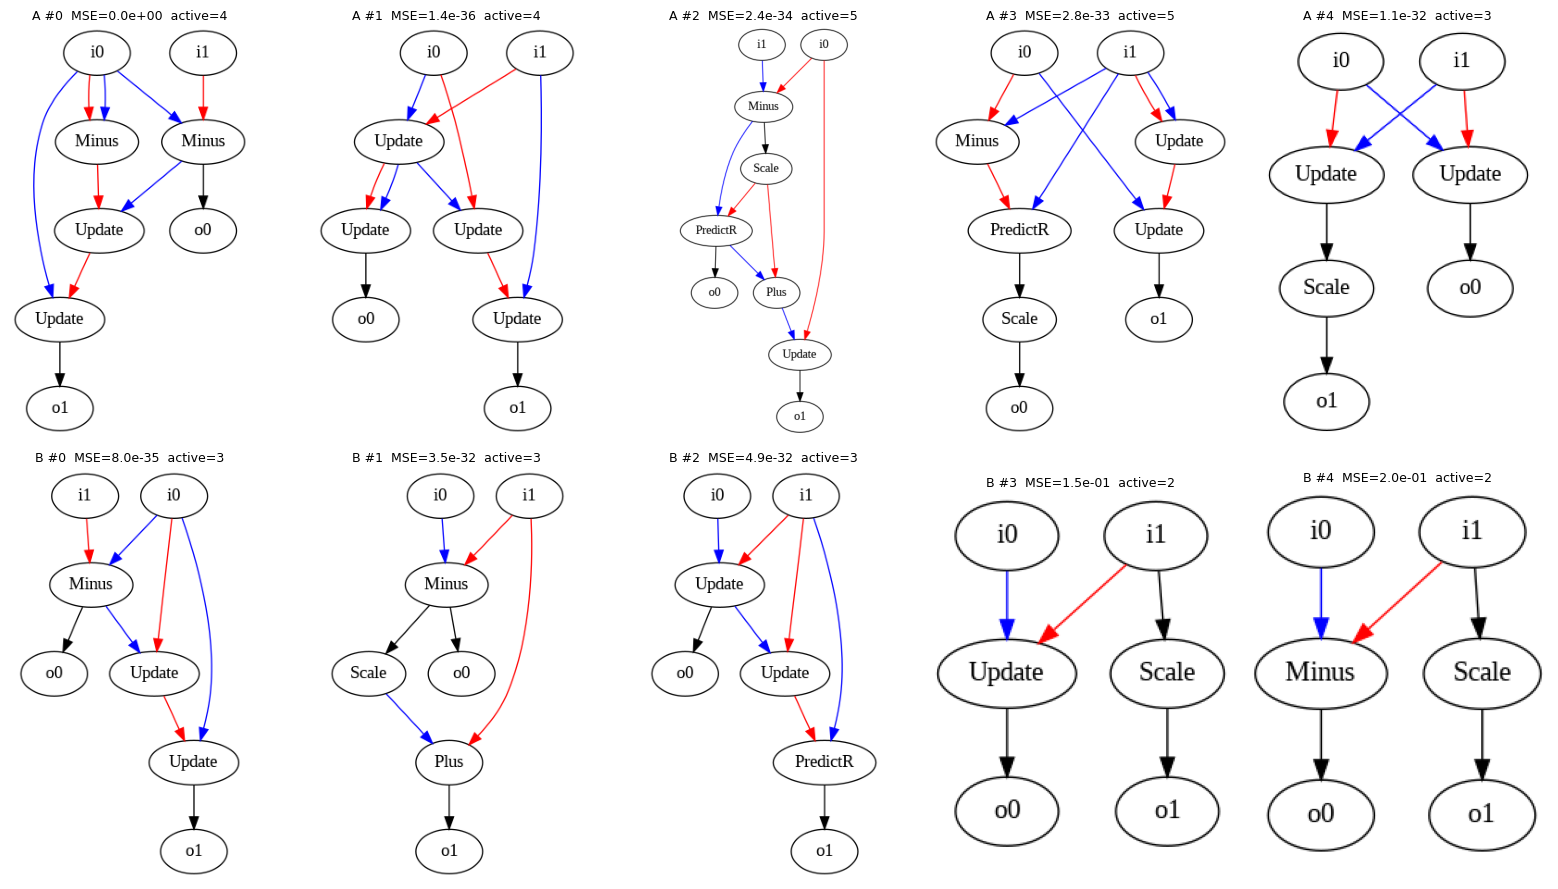

In [10]:
import io
import graphviz
from PIL import Image


def render_genome_png(gen_bytes):
    rows, cols = g.i + g.n + g.o, 1 + max(g.arity)
    gv = memoryview(bytearray(gen_bytes)).cast('B', (rows, cols))
    return Image.open(io.BytesIO(
        graphviz.Source(wavegp.as_graphviz(g, gv)).pipe(format='png')))


fig, axes = plt.subplots(2, 5, figsize=(16, 9))
for col, i in enumerate(picks_A[:5]):
    axes[0, col].imshow(render_genome_png(genomes_A[i]))
    axes[0, col].set_title(
        f"A #{col}  MSE={mse_A[i]:.1e}  active={count_active(genomes_A[i])}",
        fontsize=9)
    axes[0, col].axis('off')
for col, i in enumerate(picks_B[:5]):
    axes[1, col].imshow(render_genome_png(genomes_B[i]))
    axes[1, col].set_title(
        f"B #{col}  MSE={mse_B[i]:.1e}  active={count_active(genomes_B[i])}",
        fontsize=9)
    axes[1, col].axis('off')
plt.tight_layout()
plt.show()

## Top-100 distinct execution paths

Dedup by *active subgraph* (`wavegp.as_string(g, gen, All=False)`) —
two genomes whose dead nodes differ but whose live computation is the
same collapse into one entry.

This section collects and displays the distinct execution paths (active subgraphs) from the evolved populations, deduping by the actual computation performed rather than the full genome structure.

- **`path_signature(gen_bytes)`**: Generates a string representation of only the active (reachable) part of the genome, serving as a unique signature for the execution path.
- **`collect_paths(genomes_arr, score_arr)`**: Groups genomes by their `path_signature` and stores them, associating each signature with a list of indices of genomes that share that path.
- **`show_paths(label, genomes_arr, mse_arr, score_arr, limit)`**: Prints a table summarizing the distinct execution paths, including their rank, the number of population members sharing that path, the best MSE among them, and the active node count.

In [11]:
def path_signature(gen_bytes):
    rows, cols = g.i + g.n + g.o, 1 + max(g.arity)
    gv = memoryview(bytearray(gen_bytes)).cast('B', (rows, cols))
    return wavegp.as_string(g, gv, All=False)


def collect_paths(genomes_arr, score_arr):
    buckets = {}  # signature -> list of indices
    for i in range(len(genomes_arr)):
        buckets.setdefault(path_signature(genomes_arr[i]), []).append(i)
    keys = sorted(buckets.keys(),
                  key=lambda k: min(score_arr[i] for i in buckets[k]))
    return [(k, buckets[k]) for k in keys]


def show_paths(label, genomes_arr, mse_arr, score_arr, limit=100):
    paths = collect_paths(genomes_arr, score_arr)
    print(f"=== {label} — {len(paths)} distinct execution paths "
          f"(showing up to {limit}) ===")
    print(f"{'rank':>4}  {'pop':>4}  {'MSE':>10}  {'active':>6}")
    for rank, (key, idxs) in enumerate(paths[:limit]):
        best_i = min(idxs, key=lambda i: score_arr[i])
        n_act = count_active(genomes_arr[best_i])
        print(f"{rank:>4}  {len(idxs):>4}  {mse_arr[best_i]:>10.3e}  {n_act:>6d}")
    return paths


paths_A = show_paths("A (no bloat control)", genomes_A, mse_A, score_A)
print()
paths_B = show_paths("B (bloat-aware)",      genomes_B, mse_B, score_B)

=== A (no bloat control) — 99 distinct execution paths (showing up to 100) ===
rank   pop         MSE  active
   0     1   0.000e+00       4
   1     1   1.364e-36       4
   2     1   2.407e-34       5
   3     1   2.817e-33       5
   4     1   1.136e-32       3
   5     1   3.544e-32       3
   6     1   4.865e-32       4
   7     1   3.520e-03       4
   8     1   1.458e-01       3
   9     1   1.776e-01       6
  10     1   1.838e-01       3
  11     1   1.842e-01       4
  12     1   1.984e-01       4
  13     1   2.011e-01       4
  14     1   2.024e-01       3
  15     1   2.028e-01       2
  16     1   2.197e-01       3
  17     1   2.205e-01       3
  18     1   2.288e-01       3
  19     1   2.299e-01       3
  20     1   2.332e-01       6
  21     1   2.337e-01       4
  22     1   2.364e-01       4
  23     1   2.724e-01       4
  24     1   2.769e-01       4
  25     1   2.911e-01       3
  26     1   3.168e-01       4
  27     1   3.284e-01       3
  28     1   3.327e-01

## Active-node distribution (bloat control should shift it left)

This cell generates a histogram to visualize the distribution of active node counts in the final populations of Run A (no bloat control) and Run B (with bloat control).

- **`acts_A_pop`, `acts_B_pop`**: Arrays containing the active node counts for each genome in the final populations.
- **Plotting**: Uses `matplotlib.pyplot.hist` to create a histogram, showing how the bloat control (Run B) shifts the distribution of active nodes towards simpler programs compared to the baseline (Run A).

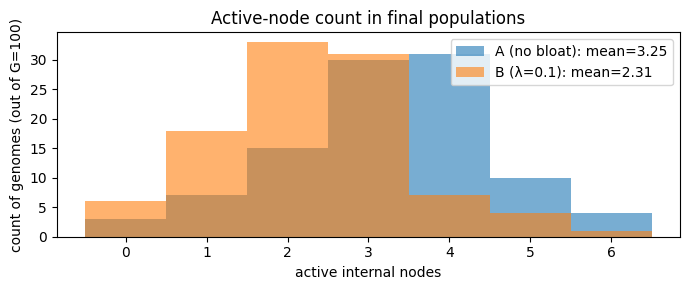

In [12]:
acts_A_pop = np.array([count_active(genomes_A[i]) for i in range(G)])
acts_B_pop = np.array([count_active(genomes_B[i]) for i in range(G)])

plt.figure(figsize=(7, 3))
bins = np.arange(0, g.n + 2) - 0.5
plt.hist(acts_A_pop, bins=bins, alpha=0.6, label=f"A (no bloat): mean={acts_A_pop.mean():.2f}")
plt.hist(acts_B_pop, bins=bins, alpha=0.6, label=f"B (λ={LAMBDA}): mean={acts_B_pop.mean():.2f}")
plt.xlabel("active internal nodes")
plt.ylabel("count of genomes (out of G=100)")
plt.title("Active-node count in final populations")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Create a DataFrame for easier plotting with seaborn
df_active_nodes = pd.DataFrame({
    'Active Nodes': np.concatenate([acts_A_pop, acts_B_pop]),
    'Run': ['A (no bloat)'] * len(acts_A_pop) + ['B (with bloat)'] * len(acts_B_pop)
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Run', y='Active Nodes', data=df_active_nodes, palette={'A (no bloat)': 'skyblue', 'B (with bloat)': 'lightcoral'})
plt.title('Distribution of Active Nodes in Final Populations')
plt.xlabel('Evolutionary Run')
plt.ylabel('Number of Active Internal Nodes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## What just happened

Both runs hit Haar (MSE → 0). Run B keeps shrinking the active
subgraph after MSE bottoms out because `MSE + λ·n_active` breaks ties
in favor of simpler structure. λ never enters LM — it would zero the
gradient signal on a discrete term.